# BariatricRSD — Data Exploration

An exploratory dive into the **MultiBypass140** dataset we're using for the NeurIPS 2026 submission. This notebook covers:

1. Dataset card & provenance
2. Video-level statistics (duration, splits, per-center)
3. Phase-level statistics (frequency, duration, transitions)
4. Intraoperative adverse event (IAE) statistics
5. Frame visualization (samples per phase, per video)
6. Video playback (embedded sample clips)
7. Phase-order cluster visualization (the paper's key conditioning signal)
8. Paper references (everything cited in the project)

**Run this on Lambda** (where the frames + videos live). The notebook is at `/lambda/nfs/bariatric-rsd/notebooks/data_exploration.ipynb` and paths are relative to that.

---
## 1. Dataset card — MultiBypass140

| | |
|---|---|
| **Paper** | Lavanchy et al., *Challenges in Multi-centric Generalization: Phase and Step Recognition in Roux-en-Y Gastric Bypass Surgery*, IJCARS 2024 |
| **arXiv** | [2312.12772](https://arxiv.org/abs/2312.12772) |
| **Code + labels** | https://github.com/CAMMA-public/MultiBypass140 |
| **Data request / S3 links** | Public S3 bucket (no form) — see repo README |
| **Videos** | 140 laparoscopic RYGB surgeries |
| **Centers** | University Hospital of Strasbourg (France) — *StrasBypass70*; Inselspital, Bern (Switzerland) — *BernBypass70* |
| **Annotations** | 12 phases, 46 steps, 5 IAE categories × 5 severity levels |
| **Frame rate in our setup** | 1 fps (total ~782k frames across 140 videos) |
| **Splits** | Official 5-fold CV; we use fold 0 for most experiments |

**Why this dataset?** It is the only public RYGB benchmark with (a) multi-center data, (b) fine-grained phase/step hierarchy, and (c) IAE labels. The multi-center aspect lets us test cross-center generalization — central to our paper's narrative about workflow variability.

In [1]:
# Setup: imports and paths
import json
import pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Adjust if you copy this notebook elsewhere
BASE = Path('/lambda/nfs/bariatric-rsd')
DATASET = BASE / 'extern/MultiBypass140/datasets/MultiBypass140'
LABELS_HEURISTIC = BASE / 'labels/mb140_fold0_labels.json'
LABELS_KMEANS    = BASE / 'labels/mb140_fold0_labels_kmeans.json'

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (11, 5)

print('Paths exist:', BASE.exists(), LABELS_KMEANS.exists())

Paths exist: True True


---
## 2. Video-level statistics

In [2]:
videos = json.load(open(LABELS_KMEANS))

rows = []
for v in videos:
    center = 'Bern' if v['video_id'].startswith('BBP') else 'Stras'
    rows.append({
        'video_id': v['video_id'],
        'center': center,
        'split': v['split'],
        'duration_min': v['total_duration_sec'] / 60,
        'n_frames': len(v['frames']),
        'n_phases': len(set(v['phase_sequence'])),
        'n_transitions': len(v['phase_sequence']) - 1,
        'phase_order_cluster': v['phase_order_cluster'],
        'has_iae': any(f['is_deviation'] for f in v['frames']),
        'iae_frames': sum(f['is_deviation'] for f in v['frames']),
    })

df = pd.DataFrame(rows)
print(f'Total videos: {len(df)}')
print(f'Total frames annotated: {df.n_frames.sum():,}')
df.head(3)

Total videos: 140
Total frames annotated: 770,701


,video_id,center,split,duration_min,n_frames,n_phases,n_transitions,phase_order_cluster,has_iae,iae_frames
0,BBP01,Bern,train,83.966667,5025,8,7,2,True,122
1,BBP02,Bern,test,126.583333,7595,9,8,2,True,441
2,BBP03,Bern,val,62.816667,3765,7,6,2,True,290


In [3]:
# Summary by center
summary = df.groupby('center').agg(
    n_videos=('video_id', 'count'),
    mean_duration_min=('duration_min', 'mean'),
    median_duration_min=('duration_min', 'median'),
    min_duration_min=('duration_min', 'min'),
    max_duration_min=('duration_min', 'max'),
    videos_with_iae=('has_iae', 'sum'),
).round(1)
summary

,n_videos,mean_duration_min,median_duration_min,min_duration_min,max_duration_min,videos_with_iae
center,,,,,,
Bern,70,73.5,72.8,37.4,144.6,69
Stras,70,110.7,112.6,40.8,178.4,69


In [4]:
# Summary by split
df.groupby('split').agg(
    n_videos=('video_id', 'count'),
    mean_duration_min=('duration_min', 'mean'),
    frames=('n_frames', 'sum'),
).round(1)

,n_videos,mean_duration_min,frames
split,,,
test,40,96.6,231305
train,80,88.0,420344
val,20,99.5,119052


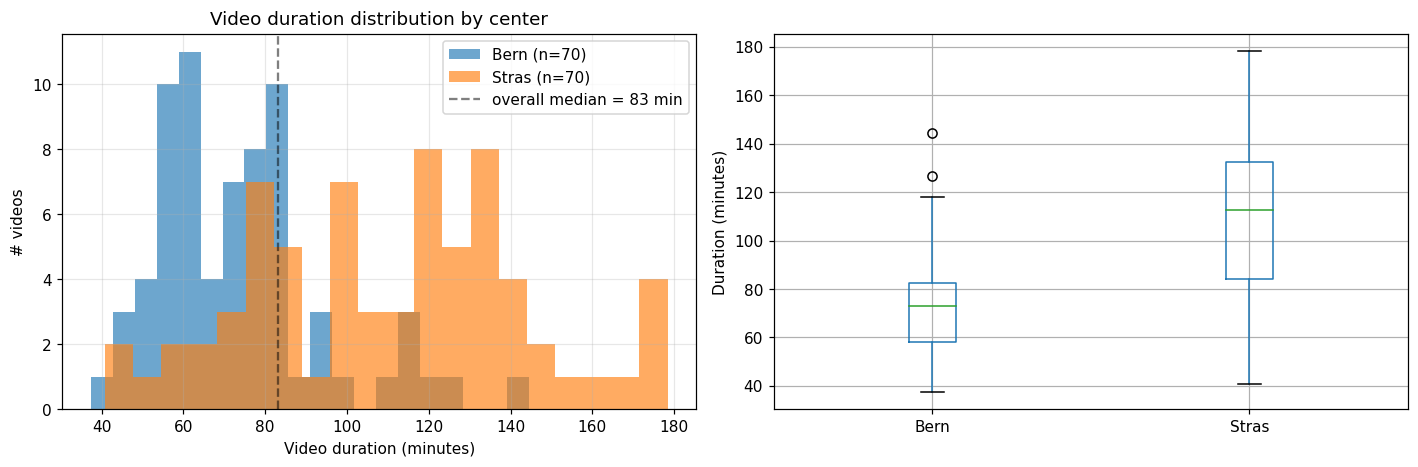

In [5]:
# Visual: duration distribution per center
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for center, color in [('Bern', 'C0'), ('Stras', 'C1')]:
    sub = df[df.center == center].duration_min
    ax[0].hist(sub, bins=20, alpha=0.65, color=color, label=f'{center} (n={len(sub)})')
ax[0].set_xlabel('Video duration (minutes)')
ax[0].set_ylabel('# videos')
ax[0].set_title('Video duration distribution by center')
ax[0].axvline(df.duration_min.median(), color='k', linestyle='--', alpha=0.5,
              label=f'overall median = {df.duration_min.median():.0f} min')
ax[0].legend()
ax[0].grid(alpha=0.3)

df.boxplot(column='duration_min', by='center', ax=ax[1])
ax[1].set_ylabel('Duration (minutes)')
ax[1].set_title('')
ax[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Key observation:** Strasbourg videos are substantially longer than Bern's — this creates a natural **workflow-variability** angle that our phase-order conditioning is designed to address.

Longer videos = more time to predict RSD accurately, but also more room for phase-order divergence.

---
## 3. Phase statistics

The MB140 ontology has 14 phase IDs (including `out_of_body` and `severe_index`):

In [6]:
# Count phase occurrences (frame-weighted)
phase_frame_counts = Counter()
phase_video_counts = Counter()
for v in videos:
    for f in v['frames']:
        phase_frame_counts[f['phase']] += 1
    for p in set(v['phase_sequence']):
        phase_video_counts[p] += 1

total_frames = sum(phase_frame_counts.values())
phase_stats = pd.DataFrame([
    {'phase': p,
     'frames': phase_frame_counts[p],
     'pct_frames': 100 * phase_frame_counts[p] / total_frames,
     'videos_appearing_in': phase_video_counts[p]}
    for p in sorted(phase_frame_counts, key=phase_frame_counts.get, reverse=True)
])
phase_stats.round(2)

,phase,frames,pct_frames,videos_appearing_in
0,Gastro-jejunal anastomosis,195918,25.42,139
1,Jejuno-jejunal anastomosis,173389,22.50,140
2,Gastric pouch creation,164181,21.30,136
3,Preparation,46098,5.98,123
4,Closure of mesenteric defect,38505,5.00,85
5,Closure of petersen's space,30617,3.97,80
6,Omentum division,25651,3.33,91
7,Cleaning/coagulation,24354,3.16,102
8,Disassembling,22968,2.98,120
9,Jejunal division,21581,2.80,139


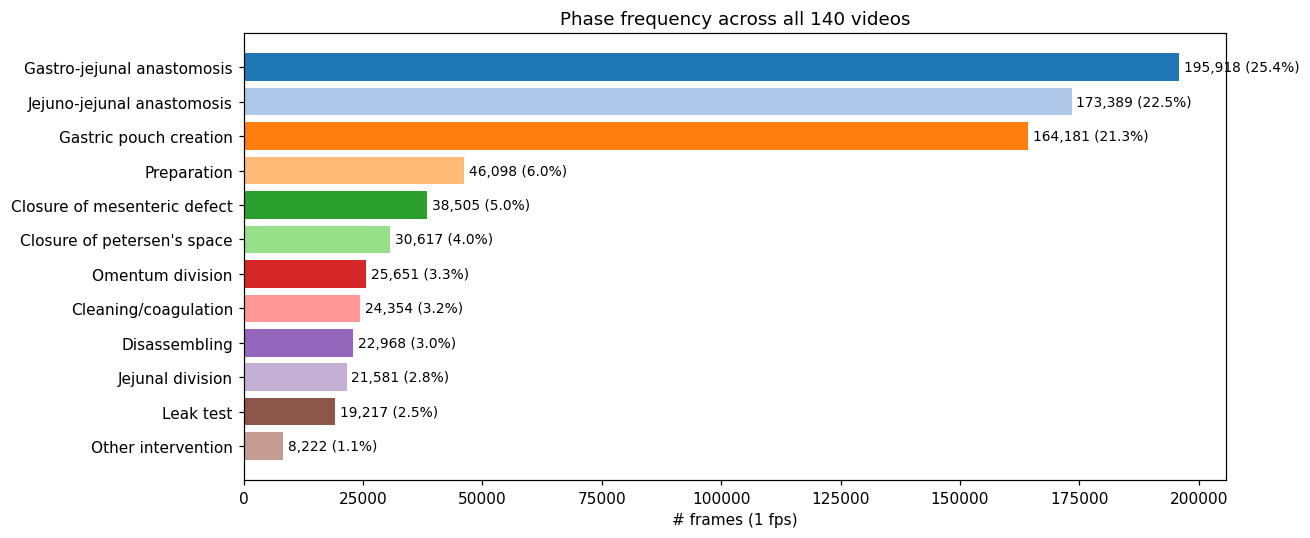

In [7]:
# Visual: phase frequency
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab20(np.arange(len(phase_stats)))
ax.barh(phase_stats.phase, phase_stats.frames, color=colors)
ax.set_xlabel('# frames (1 fps)')
ax.set_title('Phase frequency across all 140 videos')
ax.invert_yaxis()
for i, (n, p) in enumerate(zip(phase_stats.frames, phase_stats.pct_frames)):
    ax.text(n + 1000, i, f'{n:,} ({p:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

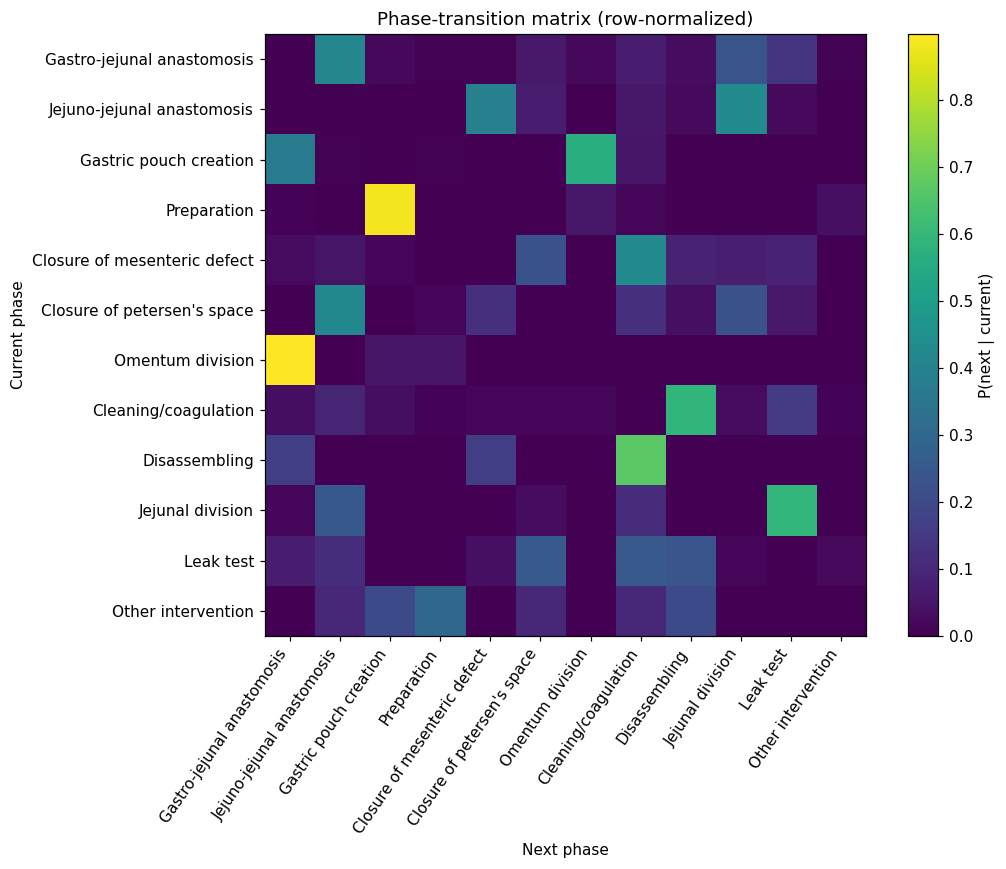

In [8]:
# Phase transition matrix (directly observed bigrams)
from collections import defaultdict
trans = defaultdict(lambda: Counter())
for v in videos:
    seq = v['phase_sequence']
    for a, b in zip(seq[:-1], seq[1:]):
        trans[a][b] += 1

phases_sorted = list(phase_stats.phase)
mat = np.zeros((len(phases_sorted), len(phases_sorted)))
for i, a in enumerate(phases_sorted):
    for j, b in enumerate(phases_sorted):
        mat[i, j] = trans[a][b]
# Row-normalize to probability
mat = mat / np.maximum(mat.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mat, cmap='viridis')
ax.set_xticks(range(len(phases_sorted)))
ax.set_yticks(range(len(phases_sorted)))
ax.set_xticklabels(phases_sorted, rotation=55, ha='right')
ax.set_yticklabels(phases_sorted)
ax.set_xlabel('Next phase')
ax.set_ylabel('Current phase')
ax.set_title('Phase-transition matrix (row-normalized)')
plt.colorbar(im, ax=ax, label='P(next | current)')
plt.tight_layout()
plt.show()

The bright diagonal is weak (we merged adjacent same-phase frames), but you can see **which phases follow which** — the paper's phase-order story lives in how different surgeons take different paths through this matrix.

---
## 4. Intraoperative adverse event (IAE) statistics

IAEs are rare but important. The MB140 IAE ontology covers 5 categories with severity 1–5:
- Bleeding
- Mechanical injury
- Thermal injury
- Ischemic injury
- Insufficient closure of anastomosis

In [9]:
iae_rows = []
for _, r in df.iterrows():
    iae_rows.append({
        'center': r.center,
        'video_id': r.video_id,
        'has_iae': r.has_iae,
        'iae_frames': r.iae_frames,
        'iae_frac': r.iae_frames / max(r.n_frames, 1),
    })
iae_df = pd.DataFrame(iae_rows)

print('Videos with any IAE:', (iae_df.has_iae).sum(), '/', len(iae_df))
print(f'Videos with IAE by center:\n{iae_df.groupby("center")["has_iae"].sum()}')
print(f'Total IAE frames: {iae_df.iae_frames.sum():,} ({100 * iae_df.iae_frames.sum() / df.n_frames.sum():.2f}% of all frames)')
iae_df.describe().round(3)

Videos with any IAE: 138 / 140
Videos with IAE by center:
center
Bern     69
Stras    69
Name: has_iae, dtype: int64
Total IAE frames: 70,366 (9.13% of all frames)


,iae_frames,iae_frac
count,140.000,140.000
mean,502.614,0.097
std,357.157,0.069
min,0.000,0.000
25%,262.250,0.054
50%,426.000,0.081
75%,659.750,0.121
max,2407.000,0.401


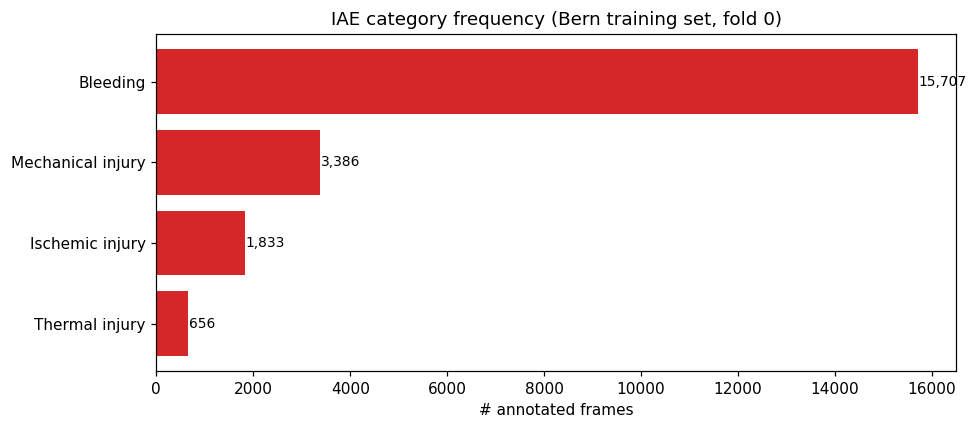

In [10]:
# Inspect a raw pickle for detailed IAE category breakdown
pickle_path = BASE / 'extern/MultiBypass140/datasets/MultiBypass140/multibypass06_corrected/labels/bern/labels/train/1fps_100_0_with_iae.pickle'
with open(pickle_path, 'rb') as f:
    iae_raw = pickle.load(f)

iae_cats = Counter()
for vid, frames in iae_raw.items():
    for fr in frames:
        for key in ['Bleeding', 'Mechanical injury', 'Thermal injury',
                    'Ischemic injury', 'Insufficient closure of anastomosis']:
            if fr.get(key, 0) > 0:
                iae_cats[key] += 1

iae_cat_df = pd.DataFrame(iae_cats.most_common(), columns=['category', 'frames'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(iae_cat_df.category, iae_cat_df.frames, color='C3')
ax.set_xlabel('# annotated frames')
ax.set_title('IAE category frequency (Bern training set, fold 0)')
ax.invert_yaxis()
for i, n in enumerate(iae_cat_df.frames):
    ax.text(n + 10, i, f'{n:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Frame visualization — sample frames per phase

Pick a representative video, grab one frame from each phase it contains, and display them.

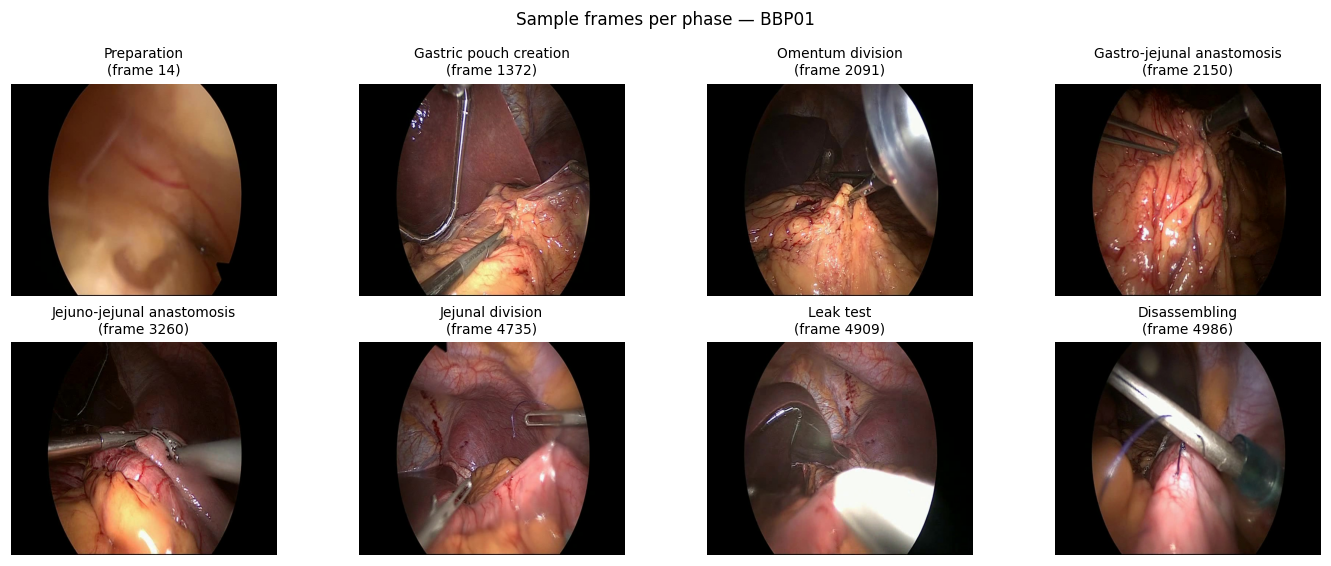

In [11]:
def frame_path(video_id, frame_idx_1based):
    center = 'BernBypass70' if video_id.startswith('BBP') else 'StrasBypass70'
    return DATASET / center / 'frames' / video_id / f'{video_id}_{frame_idx_1based:08d}.jpg'

def show_phase_montage(video_id, max_phases=8):
    v = next(x for x in videos if x['video_id'] == video_id)
    # Grab first frame per unique phase
    first_frame_per_phase = {}
    for f in v['frames']:
        first_frame_per_phase.setdefault(f['phase'], f['frame_idx'] + 1)
    items = list(first_frame_per_phase.items())[:max_phases]

    cols = 4
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 2.6))
    axes = np.atleast_2d(axes).ravel()
    for ax_i, (phase, fidx) in enumerate(items):
        p = frame_path(video_id, fidx)
        if p.exists():
            axes[ax_i].imshow(Image.open(p))
            axes[ax_i].set_title(f'{phase}\n(frame {fidx})', fontsize=9)
        else:
            axes[ax_i].text(0.5, 0.5, f'missing\n{p.name}', ha='center', va='center')
        axes[ax_i].axis('off')
    for ax_i in range(len(items), len(axes)):
        axes[ax_i].axis('off')
    plt.suptitle(f'Sample frames per phase — {video_id}', fontsize=11)
    plt.tight_layout()
    plt.show()

# Pick a Bern video
show_phase_montage('BBP01')

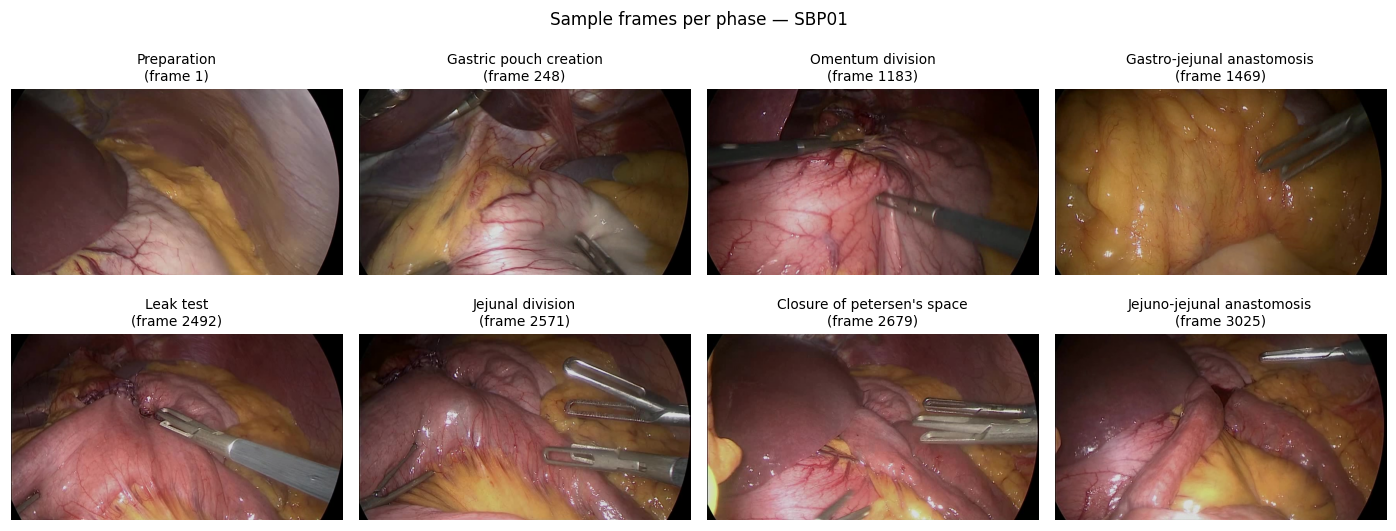

In [12]:
# And a Stras video
show_phase_montage('SBP01')

---
## 6. Video playback — sample embedded video

Embed a short clip from one of the training videos. Jupyter's `HTML5` video widget works for local files served by the Jupyter server.

⚠️ Full videos are 1–5 GB each and won't play smoothly in notebooks. For a tractable preview, we extract a **30-second clip** from the middle of the video first.

In [13]:
import subprocess

def make_preview_clip(video_id, start_sec=1200, duration=30, out_dir='/tmp'):
    """Extract a short clip for notebook preview."""
    center = 'BernBypass70' if video_id.startswith('BBP') else 'StrasBypass70'
    src = DATASET / center / 'videos' / f'{video_id}.mp4'
    dst = Path(out_dir) / f'{video_id}_preview.mp4'
    if not dst.exists():
        cmd = [
            'ffmpeg', '-y', '-loglevel', 'error',
            '-ss', str(start_sec), '-i', str(src),
            '-t', str(duration),
            '-vf', 'scale=640:-2',
            '-c:v', 'libx264', '-crf', '28', '-preset', 'ultrafast',
            str(dst)
        ]
        subprocess.run(cmd, check=True)
    return dst

preview = make_preview_clip('BBP01', start_sec=1200, duration=30)
print(f'Created {preview} — size: {preview.stat().st_size/1e6:.1f} MB')

Created /tmp/BBP01_preview.mp4 — size: 5.1 MB


In [14]:
from IPython.display import Video
Video(str(preview), embed=True, width=640)

---
## 7. Phase-order clustering visualization

This is the paper's scientific centerpiece. We cluster the 140 videos by their phase-transition patterns and use the cluster ID as an additional input token to the Transformer. See Run 006 in the main walkthrough — this conditioning buys ~1.3 minutes of val_mae improvement.

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


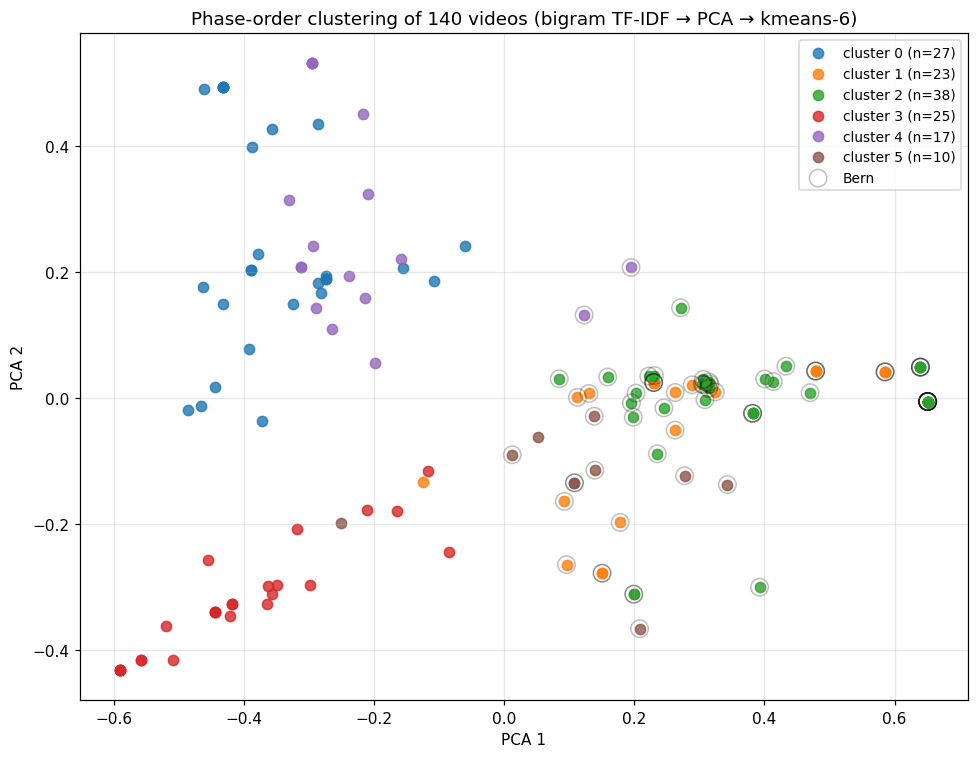

In [15]:
# Recreate the k-means + PCA embedding for visualization
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

def phase_bigrams(seq):
    toks = [p.lower().replace(' ', '_').replace("'", '') for p in seq]
    return ' '.join(f'{a}->{b}' for a, b in zip(toks[:-1], toks[1:]))

docs = [phase_bigrams(v['phase_sequence']) for v in videos]
vec = TfidfVectorizer(token_pattern=r'\S+', min_df=2, sublinear_tf=True)
X = vec.fit_transform(docs).toarray()
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
km = KMeans(n_clusters=6, n_init=20, random_state=42)
cluster_ids = km.fit_predict(PCA(n_components=16, random_state=42).fit_transform(X))

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(6):
    m = cluster_ids == c
    ax.scatter(X2[m, 0], X2[m, 1], label=f'cluster {c} (n={m.sum()})', alpha=0.8, s=45)
# Mark centers differently
bern_mask = df.center.values == 'Bern'
ax.scatter(X2[bern_mask, 0], X2[bern_mask, 1], marker='o', facecolors='none', edgecolors='k',
           s=130, alpha=0.25, label='Bern')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_title('Phase-order clustering of 140 videos (bigram TF-IDF → PCA → kmeans-6)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Show representative phase sequences per cluster
for c in range(6):
    members = [v for v, cid in zip(videos, cluster_ids) if cid == c]
    print(f'\n=== Cluster {c} (n={len(members)}) ===')
    centers = Counter(('Bern' if v['video_id'].startswith('BBP') else 'Stras') for v in members)
    print(f'  Center mix: {dict(centers)}')
    for v in members[:2]:
        seq = ' → '.join(v['phase_sequence'][:7])
        print(f'  {v["video_id"]}: {seq}...')


=== Cluster 0 (n=27) ===
  Center mix: {'Stras': 27}
  SBP01: Preparation → Gastric pouch creation → Omentum division → Gastric pouch creation → Omentum division → Gastro-jejunal anastomosis → Leak test...
  SBP07: Jejuno-jejunal anastomosis → Closure of mesenteric defect → Cleaning/coagulation → Disassembling...

=== Cluster 1 (n=23) ===
  Center mix: {'Bern': 22, 'Stras': 1}
  BBP04: Preparation → Gastric pouch creation → Omentum division → Gastro-jejunal anastomosis → Jejuno-jejunal anastomosis → Jejunal division → Cleaning/coagulation...
  BBP12: Preparation → Gastric pouch creation → Omentum division → Gastro-jejunal anastomosis → Jejuno-jejunal anastomosis → Jejunal division → Leak test...

=== Cluster 2 (n=38) ===
  Center mix: {'Bern': 38}
  BBP01: Preparation → Gastric pouch creation → Omentum division → Gastro-jejunal anastomosis → Jejuno-jejunal anastomosis → Jejunal division → Leak test...
  BBP02: Preparation → Gastric pouch creation → Omentum division → Gastro-jejunal an

**Interpretation:** Notice how clusters split meaningfully by center AND by intra-center ordering variation. Bern videos (BBP) and Stras videos (SBP) don't merge into single clusters — surgeons at different hospitals really do sequence things differently. This is exactly what the phase-order token is supposed to encode.

---
## 8. Paper references

### Directly used in this project

| Ref | What we use | Link |
|-----|-------------|------|
| **MultiBypass140** (Lavanchy et al., IJCARS 2024) | The dataset itself | [arXiv:2312.12772](https://arxiv.org/abs/2312.12772) • [repo](https://github.com/CAMMA-public/MultiBypass140) |
| **Surgformer** (Yang et al., MICCAI 2024) | Hierarchical Temporal Attention architecture adapted as our temporal backbone | [arXiv:2408.03867](https://arxiv.org/abs/2408.03867) • [repo](https://github.com/isyangshu/Surgformer) |
| **HecVL** (Yuan et al., MICCAI 2024) | Would provide surgical-domain visual encoder weights — repo is private, not yet accessible | [arXiv:2405.10075](https://arxiv.org/abs/2405.10075) |
| **PeskaVLP** (Yuan et al., NeurIPS 2024) | Procedure-aware surgical VLP — alternative encoder initialization to explore | [arXiv:2411.14468](https://arxiv.org/abs/2411.14468) |
| **Cholec80** (Twinanda et al., IEEE TMI 2017) | Cholecystectomy benchmark for RSD baseline comparison | [camma.u-strasbg.fr/datasets](http://camma.u-strasbg.fr/datasets) |
| **timm** (Wightman) | ViT encoder backbone (`vit_base_patch16_224`) | [repo](https://github.com/huggingface/pytorch-image-models) |
| **Kendall et al. 2018** | Uncertainty-weighted multi-task loss (log-variance parameterization) | [arXiv:1705.07115](https://arxiv.org/abs/1705.07115) |

### SOTA baselines cited in the paper's target table

| Ref | Claim | Dataset |
|-----|-------|---------|
| **TransLocal** | 7.1 min RSD MAE on Cholec80 | Cholec80 |
| **BetaMixer** | 0.76 deviation F1 on MultiBypass140 | MultiBypass140 |

### NeurIPS structural references (studied for paper framing, from GPT_plan.md)

- *Why do tree-based models still outperform deep learning on typical tabular data?* (Grinsztajn et al., NeurIPS 2022) — model for careful empirical argument
- *Flamingo: a Visual Language Model for Few-Shot Learning* (Alayrac et al., NeurIPS 2022)
- *Perception Test* (Patraucean et al., NeurIPS 2023) — diagnostic evaluation framing
- *LongVideoBench* (NeurIPS 2024) — long video understanding benchmark
- *MMBench-Video* — multimodal video benchmark
- *HEMM* (NeurIPS 2024) — model for emphasizing evaluation quality
- *Video Token Merging for Long Video Understanding* — efficiency framing

### Venue documents (for formatting + review expectations)

- [NeurIPS 2026 Call for Papers](https://neurips.cc/Conferences/2026/CallForPapers)
- [NeurIPS 2026 Main Track Handbook](https://neurips.cc/Conferences/2026)
- [NeurIPS 2026 Evaluations & Datasets track](https://neurips.cc/Conferences/2026/CallForDatasetsBenchmarks) — contingency track if the method gain is modest
- [NeurIPS Paper Checklist](https://neurips.cc/public/guides/PaperChecklist)

---
## Appendix — quick stats TL;DR

Run this cell to get a one-page summary anyone on the team can read.

In [ ]:
print(f'''\
MultiBypass140 — fold 0 summary
================================
Videos:                  {len(df)}
  Bern:                  {(df.center=="Bern").sum()}
  Stras:                 {(df.center=="Stras").sum()}
Splits:
  Train:                 {(df.split=="train").sum()}
  Val:                   {(df.split=="val").sum()}
  Test:                  {(df.split=="test").sum()}

Durations (minutes):
  Overall median:        {df.duration_min.median():.1f}
  Bern median:           {df[df.center=="Bern"].duration_min.median():.1f}
  Stras median:          {df[df.center=="Stras"].duration_min.median():.1f}

Frames (1 fps):
  Total annotated:       {df.n_frames.sum():,}

Phases seen per video:
  Mean unique phases:    {df.n_phases.mean():.1f}
  Mean transitions:      {df.n_transitions.mean():.1f}

IAE (intraoperative adverse events):
  Videos with any IAE:   {df.has_iae.sum()} / {len(df)}
  Fraction of all frames with IAE: {100 * df.iae_frames.sum() / df.n_frames.sum():.2f}%

Phase-order clusters (kmeans, k=6):
  Cluster sizes:         {dict(Counter(df.phase_order_cluster.tolist()))}
''')